# Stratified K-Fold Cross-Validation for DeepSurv  

Recall that in a [single-layer neural network](https://ucla-biostat-274.github.io/2026winter/slides/11-nn/nn_only.html#single-layer-neural-network) where $X_j$ are the inputs and $A_k$ are the hidden layers, the model is: 

$$
f(X) = \beta_0 + \sum_{k=1}^K \beta_k A_k
$$

where $A_k = g(w_{k0}+\sum_{j=1}^p w_{kj}X_j)$ is the **Activation** or **Hidden Layer**. 

$g(z)$ is the **activation function** which can be something like a **sigmoid** or **rectified linear (ReLU)** function  

When you conduct cross-validation for a neural-network, you generally need to optimize/save the best parameters for:  
1. weights ($w_{kj}$)  
2. learning rate (`lr`)  

Recall, in the example in `02_penalizedCoxPH.ipynb` we determined the "best" parameters for our model based on the c-index. Now that we work with Neural Nets, we now optimize based on the validation losses. 


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn_pandas import DataFrameMapper
from sklearn.model_selection import StratifiedKFold, train_test_split


import torch
import torchtuples as tt

from sksurv.datasets import load_breast_cancer
from sksurv.preprocessing import OneHotEncoder

from pycox.models import CoxPH
from pycox.evaluation import EvalSurv

## MUST RUN THIS TO AVOID ISSUES WITH SCIPY INTEGRATE
import scipy.integrate as integ

# Provide a backwards-compat alias for pycox
if not hasattr(integ, "simps") and hasattr(integ, "simpson"):
    def simps(y, x, **kwargs):
        return integ.simpson(y, x=x, **kwargs)
    integ.simps = simps

Some helpful functions: 

In [17]:
def _set_seed(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)

def get_target(y_struct, event_field="e.tdm", time_field="t.tdm"):
    events = y_struct[event_field].astype(np.int64)      # True/False -> 1/0
    durations = y_struct[time_field].astype(np.float32)  # float32 is fine
    return (durations, events)

Import original data

In [11]:
X, y = load_breast_cancer()
Xt = OneHotEncoder().fit_transform(X)

## Cross-Validation

### Define Out-of-Loop Parameters 

In [12]:
event_indicator = y["e.tdm"]
Xt_col_names = Xt.columns.tolist()
cols_leave = ['er=positive', 'grade=intermediate', 'grade=poorly differentiated', 'grade=unkown']
cols_standardize = [col for col in Xt_col_names if col not in cols_leave]

# Define the DataFrameMapper which takes any feature matrix and standardizes the features in cols_standardize and leaves the features in cols_leave alone
standardize = [([col], StandardScaler()) for col in cols_standardize]
leave = [(col, None) for col in cols_leave]

x_mapper = DataFrameMapper(standardize + leave)

# Define number of Run, Splits (Folds), and Test_Size, learning rates to test
n_runs = 5
n_splits = 5
test_size = 0.1
learning_rates = [1e-4, 1e-5]
random_state = 1234

metrics_summary = {
    'run': [],
    'fold': [],
    'best_lr': [],
    'best_valid_loss': [],
    'c_index': [],
    'ibs': []
}


### Cross-Validation Loop

In [ ]:
for run in range(n_runs):
    print(f"\n=== Run {run + 1} ===")
    _set_seed(random_state + run) # unique seed for each run
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state + run)

    for fold, (trainval_index, test_index) in enumerate(kf.split(Xt, event_indicator)):
        print(f'\n--- Fold {fold + 1} ---')
        X_trainval, X_test = Xt.iloc[trainval_index], Xt.iloc[test_index]
        y_trainval, y_test = y[trainval_index], y[test_index]

        # Split into Train + Validation
        X_train, X_val, y_train, y_val = train_test_split(
                    X_trainval, 
                    y_trainval, 
                    test_size=test_size, 
                    random_state=random_state + run + fold)

        # TRANSFORM features 
        X_train_sc = x_mapper.fit_transform(X_train).astype('float32')
        X_val_sc = x_mapper.transform(X_val).astype('float32')
        X_test_sc = x_mapper.transform(X_test).astype('float32')

        # Convert Targets to Tuples
        y_train_tup = get_target(y_train)   # (durations_train, events_train)
        y_val_tup   = get_target(y_val)
        y_test_tup  = get_target(y_test)

        val = (X_val_sc, y_val_tup)

        best_valid_loss = float("inf")
        best_lr = None
        best_fold_metrics = None

        for lr in learning_rates: 
            print(f'\nTraining with learning rate: {lr}')
            in_features = X_train_sc.shape[1]
            num_nodes = [32, 32]
            out_features = 1
            batch_norm = True
            dropout = 0.1
            output_bias = False

            net = tt.practical.MLPVanilla(in_features, num_nodes, out_features, batch_norm,
                              dropout, output_bias=output_bias)
            model = CoxPH(net, tt.optim.Adam) # <- Use Adam optimizer (pretty standard)
            model.optimizer.set_lr(lr)
            epochs = 100 
            batch_size = 64 # <- batch is a small subset of training data used to compute one gradient update at a time 
            callbacks = [tt.callbacks.EarlyStopping()] # You can set your epochs as high as you need to, but essentially your validation metrics stop improving/show marginal improvements
            verbose = True 

            # train the model
            log = model.fit(X_train_sc, y_train_tup, batch_size, epochs, callbacks, verbose, val_data=val, val_batch_size=batch_size)
            temp_val_loss= np.min(log.to_pandas()['val_loss'])

            print(f"Minimum validation loss: {temp_val_loss:.4f}")

            # compute metrics (you can also do this if the temp_val_loss < best_valid_loss)
            _ = model.compute_baseline_hazards()
            surv = model.predict_surv_df(X_test_sc)

            durations_test, events_test = y_test_tup
            ev = EvalSurv(surv, durations_test, events_test, censor_surv='km')
            c_index = ev.concordance_td()

            ## Integrated Brier Score
            time_grid = np.linspace(durations_test.min(), durations_test.max(), 100)
            ibs = ev.integrated_brier_score(time_grid)

            if temp_val_loss < best_valid_loss: 
                best_valid_loss = temp_val_loss
                best_lr = lr 
                best_fold_metrics = (c_index, ibs)
            else: 
                print(f"(No improvement; best val loss still {best_valid_loss:.5f})")
        print(f"Best learning rate: {best_lr}, TEST C-index: {best_fold_metrics[0]:.4f}, TEST IBS: {best_fold_metrics[1]:.4f}")
        metrics_summary['run'].append(run + 1)
        metrics_summary['fold'].append(fold + 1)
        metrics_summary['best_lr'].append(best_lr)
        metrics_summary['best_valid_loss'].append(best_valid_loss)
        metrics_summary['c_index'].append(best_fold_metrics[0])
        metrics_summary['ibs'].append(best_fold_metrics[1])

metrics_df = pd.DataFrame(metrics_summary)


=== Run 1 ===

--- Fold 1 ---

Training with learning rate: 0.0001
0:	[0s / 0s],		train_loss: 3.8037,	val_loss: 2.7596
1:	[0s / 0s],		train_loss: 3.7357,	val_loss: 2.7479
2:	[0s / 0s],		train_loss: 3.6156,	val_loss: 2.7170
3:	[0s / 0s],		train_loss: 3.4561,	val_loss: 2.6848
4:	[0s / 0s],		train_loss: 3.5777,	val_loss: 2.6672
5:	[0s / 0s],		train_loss: 3.3497,	val_loss: 2.6545
6:	[0s / 0s],		train_loss: 3.6061,	val_loss: 2.6327
7:	[0s / 0s],		train_loss: 3.4954,	val_loss: 2.5977
8:	[0s / 0s],		train_loss: 3.5312,	val_loss: 2.6052
9:	[0s / 0s],		train_loss: 3.6510,	val_loss: 2.6089
10:	[0s / 0s],		train_loss: 3.6480,	val_loss: 2.5939
11:	[0s / 0s],		train_loss: 3.5810,	val_loss: 2.5905
12:	[0s / 0s],		train_loss: 3.4298,	val_loss: 2.5876
13:	[0s / 0s],		train_loss: 3.6425,	val_loss: 2.5738
14:	[0s / 0s],		train_loss: 3.6568,	val_loss: 2.5767
15:	[0s / 0s],	
16:	[0s / 0s],	
17:	[0s / 0s],	
18:	[0s / 0s],	
19:	[0s / 0s],	
20:	[0s / 0s],	
21:	[0s / 0s],	
22:	[0s / 0s],	
23:	[0s / 0s],	
Min

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.



Training with learning rate: 1e-05
0:	[0s / 0s],		train_loss: 3.7046,	val_loss: 2.7951
1:	[0s / 0s],		train_loss: 3.6218,	val_loss: 2.7566
2:	[0s / 0s],		train_loss: 3.5498,	val_loss: 2.7244
3:	[0s / 0s],		train_loss: 3.5322,	val_loss: 2.7297
4:	[0s / 0s],		train_loss: 3.5001,	val_loss: 2.7424
5:	[0s / 0s],		train_loss: 3.4641,	val_loss: 2.7681
6:	[0s / 0s],		train_loss: 3.6623,	val_loss: 2.7841
7:	[0s / 0s],		train_loss: 3.7249,	val_loss: 2.8048
8:	[0s / 0s],		train_loss: 3.5340,	val_loss: 2.8276
9:	[0s / 0s],		train_loss: 3.8356,	val_loss: 2.8401
10:	[0s / 0s],		train_loss: 3.2430,	val_loss: 2.8413
11:	[0s / 0s],		train_loss: 3.6162,	val_loss: 2.8336
12:	[0s / 0s],		train_loss: 3.4981,	val_loss: 2.8497
Minimum validation loss: 2.7244
(No improvement; best val loss still 2.57380)
Best learning rate: 0.0001, TEST C-index: 0.5434, TEST IBS: 0.1543

--- Fold 2 ---

Training with learning rate: 0.0001
0:	[0s / 0s],		train_loss: 3.5063,	val_loss: 2.9337
1:	[0s / 0s],		train_loss: 3.4185,	

In [19]:
print(metrics_df)

    run  fold  best_lr  best_valid_loss   c_index       ibs
0     1     1  0.00010         2.573798  0.543408  0.154312
1     1     2  0.00001         2.391805  0.527950  0.182563
2     1     3  0.00001         2.781603  0.426471  0.163689
3     1     4  0.00010         2.638240  0.440129  0.244634
4     1     5  0.00010         2.452787  0.576512  0.143885
5     2     1  0.00001         2.426712  0.481366  0.176600
6     2     2  0.00010         2.188868  0.446108  0.223818
7     2     3  0.00010         2.402455  0.525000  0.149400
8     2     4  0.00001         2.506170  0.537313  0.155064
9     2     5  0.00001         2.566950  0.438095  0.188829
10    3     1  0.00010         2.450002  0.640669  0.175380
11    3     2  0.00001         1.186368  0.609428  0.171028
12    3     3  0.00010         2.078187  0.603030  0.177783
13    3     4  0.00001         2.760335  0.357401  0.171205
14    3     5  0.00001         2.531239  0.652921  0.152332
15    4     1  0.00010         2.570257 

### Results

We write a function to help us visualize our results

In [22]:
def plot_hist(
    values: np.ndarray,
    mean: float,
    ref_value: float,
    bins: int = 15,
    title: str = "Histogram",
    xlabel: str = "Value",
) -> None:
    values = np.asarray(values)

    plt.figure()
    plt.hist(values, bins=bins, edgecolor="black", alpha=0.7)

    # Mean line
    plt.axvline(mean, linestyle="--", linewidth=2, label=f"Mean = {mean:.3f}", color = 'red')

    # Reference line
    plt.axvline(ref_value, linestyle="-", linewidth=2, label=f"Random Guess = {ref_value:.3f}", color = 'black')

    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.title(title)
    plt.legend()
    plt.show()

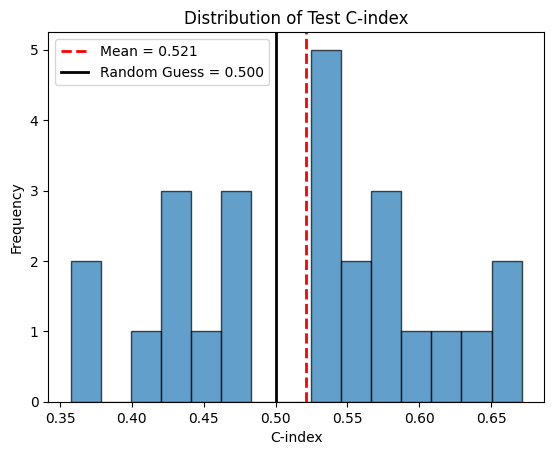

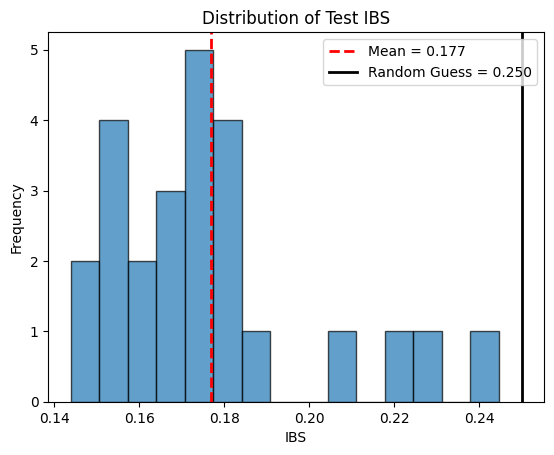

In [25]:
# Extract values
cindex_values = metrics_df['c_index'].values
ibs_values = metrics_df['ibs'].values

# Compute means
mean_cindex = np.mean(cindex_values)
mean_ibs = np.mean(ibs_values)

plot_hist(cindex_values, mean_cindex, ref_value = 0.5, title = "Distribution of Test C-index", xlabel = "C-index")
plot_hist(ibs_values, mean_ibs, ref_value=0.25, title = "Distribution of Test IBS", xlabel = "IBS")



## Some Red-Flags to Watch For  

1. Validation/Test Performance is "Too Good"  
- This might look like a validation or test C-index being very close to 1, which may suggest that Training = Validation  
- Culprit: Data Leakage (i.e, when your model "cheats" or "sees" the test or validation set as part of its training) 
2. Preprocessing Happening outside the CV loop  
- Example: you do `Xt_sc = x_mapper.fit_transform(Xt)` outside of the fold and then inside the fold you then do `X_train = Xt_sc.iloc[train_idx]`
3. Performance is suspiciously stable across random seeds --> Check that you are seeding correctly. 
4. You report Validation instead of your metrics for Test



